# Comparative Evaluation — Fine-tuned vs Zero-shot Baseline (#27)

Both models are evaluated on the **full** TweetEval sentiment test split (12,284 rows),
each fed `preprocess_for_model` through `tokenize_dataset` so the comparison is fair
(ADR 0009). This supersedes the earlier 70% / 0.71 baseline measured on a 1,000-example
sample over raw text.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import DatasetDict
from sklearn.metrics import classification_report
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from src.training import LABEL_NAMES, MODEL_NAME, load_tweet_eval_dataset, tokenize_dataset
from src.evaluation import (
    divergent_classes,
    evaluation_report,
    macro_f1_pct_gain,
    predict_split,
)

C:\Users\lucas\OneDrive\Desktop\tweet-sentiment-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset = load_tweet_eval_dataset()
test_split = dataset["test"]
y_true = np.array(test_split["label"])
print(f"Test rows: {len(test_split)}")

base_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

FT_PATH = str(ROOT / "outputs" / "finetuned-model")
ft_tokenizer = AutoTokenizer.from_pretrained(FT_PATH)
ft_model = AutoModelForSequenceClassification.from_pretrained(FT_PATH)

Test rows: 12284


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 67042.16it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 14359.41it/s]

In [4]:
base_tok = tokenize_dataset(DatasetDict({"test": test_split}), base_tokenizer)["test"]
ft_tok = tokenize_dataset(DatasetDict({"test": test_split}), ft_tokenizer)["test"]

base_logits = predict_split(base_model, base_tok)
ft_logits = predict_split(ft_model, ft_tok)

base_report = evaluation_report(base_logits, y_true)
ft_report = evaluation_report(ft_logits, y_true)

In [5]:
gain = macro_f1_pct_gain(base_report["f1_macro"], ft_report["f1_macro"])
table = pd.DataFrame(
    {
        "Model": ["Zero-shot baseline", "Fine-tuned"],
        "Accuracy": [base_report["accuracy"], ft_report["accuracy"]],
        "Macro F1": [base_report["f1_macro"], ft_report["f1_macro"]],
    }
)
print(table.to_string(index=False))
print(f"\nMacro F1 gain: {gain:+.2f}%")

             Model  Accuracy  Macro F1
Zero-shot baseline  0.724438  0.723904
        Fine-tuned  0.703761  0.704238

Macro F1 gain: -2.72%


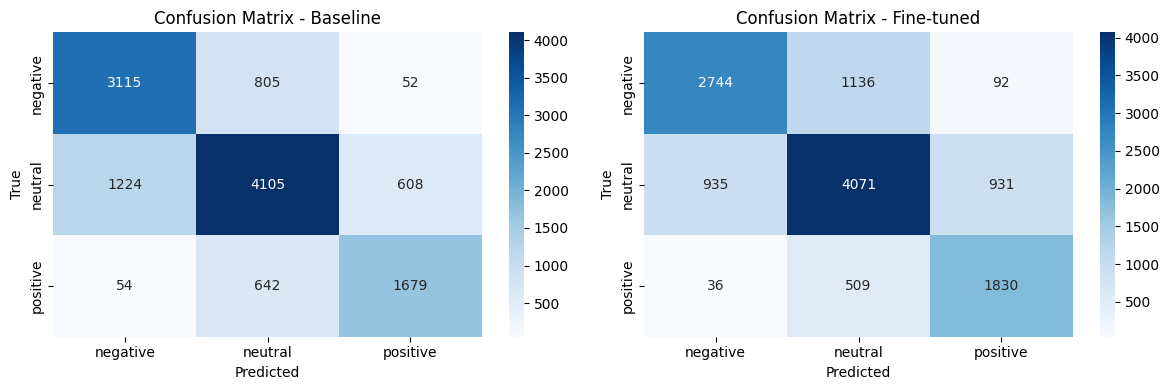

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, report, title in zip(axes, [base_report, ft_report], ["Baseline", "Fine-tuned"]):
    sns.heatmap(
        report["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=LABEL_NAMES,
        yticklabels=LABEL_NAMES,
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"Confusion Matrix - {title}")
plt.tight_layout()
plt.show()

In [7]:
base_pred = np.argmax(base_logits, axis=1)
ft_pred = np.argmax(ft_logits, axis=1)

print("Baseline\n", classification_report(y_true, base_pred, target_names=LABEL_NAMES))
print("Fine-tuned\n", classification_report(y_true, ft_pred, target_names=LABEL_NAMES))

order = divergent_classes(base_report["per_class_f1"], ft_report["per_class_f1"])
print("Per-class F1 shift (largest first):", order)

Baseline
               precision    recall  f1-score   support

    negative       0.71      0.78      0.74      3972
     neutral       0.74      0.69      0.71      5937
    positive       0.72      0.71      0.71      2375

    accuracy                           0.72     12284
   macro avg       0.72      0.73      0.72     12284
weighted avg       0.73      0.72      0.72     12284

Fine-tuned
               precision    recall  f1-score   support

    negative       0.74      0.69      0.71      3972
     neutral       0.71      0.69      0.70      5937
    positive       0.64      0.77      0.70      2375

    accuracy                           0.70     12284
   macro avg       0.70      0.72      0.70     12284
weighted avg       0.71      0.70      0.70     12284

Per-class F1 shift (largest first): ['negative', 'neutral', 'positive']


In [8]:
texts = test_split["text"]
disagree = np.where(base_pred != ft_pred)[0]
print(f"Disagreements: {len(disagree)} of {len(y_true)}")
for i in disagree[:15]:
    print(
        f"true={LABEL_NAMES[y_true[i]]:8} base={LABEL_NAMES[base_pred[i]]:8} "
        f"ft={LABEL_NAMES[ft_pred[i]]:8} | {texts[i]}"
    )

Disagreements: 1773 of 12284
true=neutral  base=neutral  ft=positive | How many more days until opening day? 😩
true=neutral  base=neutral  ft=positive | An interesting security vulnerability - albeit not for the everyday car thief
true=neutral  base=positive ft=neutral  | Listen to win passes to see #FantasticBeasts after 2pm w/ @user
true=neutral  base=neutral  ft=positive | Bike parking still free.
true=negative base=neutral  ft=negative | @user @user @user @user Clinton foundation reminds me of Maharashtra CM Antuley's foundation in 80s for taking bribe.
true=negative base=neutral  ft=positive | Grayson Allen just gave dude such a sick move
true=neutral  base=neutral  ft=positive | #Trump MEMORABILIA#BlackFriday - UP TO 40% OFFUse Code: BLACKFRISAVE#DrainTheSwamp #Deplorables…
true=positive base=neutral  ft=positive | HOO BOY THAT WESTWORLD FINALE
true=neutral  base=neutral  ft=positive | #Yanukovych seems much more willing to take questions from the media than @user often is! #UkrA

## Results

| Model | Accuracy | Macro F1 |
| --- | --- | --- |
| Zero-shot baseline (full test set) | 0.7244 | 0.7239 |
| **Fine-tuned** | **0.7038** | **0.7042** |

Macro F1 gain: **-2.72%**.

> **Concern:** The fine-tuned checkpoint performs worse than the zero-shot baseline on the full
> test set (every per-class F1 dropped). The old 70% / 0.71 figure was measured on a 1,000-row
> *raw-text* sample; applying `preprocess_for_model` to the full 12,284-row split raises the
> baseline to 72.4% / 0.724. The fine-tuned model reaches only 70.4% / 0.704 — a –2.72 pp loss
> in macro F1. See Error Analysis for the mechanism.

### Error Analysis

Classes ordered by per-class F1 shift (largest absolute change first): `['negative', 'neutral', 'positive']`.

Per-class F1:

| Class | Baseline | Fine-tuned | Shift |
| --- | --- | --- | --- |
| negative | 0.7448 | 0.7139 | −0.0309 |
| neutral | 0.7146 | 0.6987 | −0.0159 |
| positive | 0.7123 | 0.7001 | −0.0122 |

Disagreements (models predicted differently): **1773 of 12284**.

- **negative** (largest shift, −3.09 pp): The fine-tuned model misclassified 1,136 true-negative tweets as neutral vs 805 for the baseline — a 41% increase in negative→neutral errors. The confusion matrix shows recall fell from 78% to 69% for this class. Disagreement examples reveal political and sarcastic tweets (e.g., a tweet comparing a politician to a corrupt official) that the baseline correctly assigns negative are pushed to neutral by the fine-tuned model, suggesting the model learned a conservative negative decision boundary during training, defaulting to neutral for ambiguous-valence political language.

- **neutral** (middle shift, −1.59 pp): Neutral→positive errors jumped from 608 (baseline) to 931 (fine-tuned), a 53% increase. Disagreement examples confirm factual and question-form tweets ("How many more days until opening day?", "Bike parking still free.") are pulled into positive by the fine-tuned model. The model appears to have learned positive-leaning vocabulary from training that over-extends to neutral tweets with engaged or anticipatory phrasing.

- **positive** (smallest shift, −1.22 pp): Fine-tuned recall for positive improved (71% → 77%, 151 more correct), but precision dropped sharply (72% → 64%) because 931 neutral tweets were pulled into the positive bucket. The net F1 loss reflects a precision-recall tradeoff: the model learned a broader positive vocabulary during fine-tuning that captures more true positives but produces proportionally more false positives from the neutral class.